# `risk545` — Functional Tests 1 walkthrough

This notebook is a guided tour of the `risk545` package: what each function
does, why it's built the way it is, and how it reproduces the class's
reference test outputs in `testfiles/data/`.

It covers tests 1 through 7.6 -- missing-data statistics, exponential
weighting, non-PSD matrix repair, Cholesky, Monte Carlo simulation, return
calculation, and distribution fitting (Normal, Student's t, and the NIG two
ways). The automated pass/fail version of everything here lives in
`tests/test_functional.py` -- run `pytest tests/test_functional.py -v` from
the repo root to check it all at once.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Walk up from this notebook until we find the repo root (marked by
# pyproject.toml), so this works regardless of where Jupyter was launched.
_here = Path.cwd()
for _candidate in [_here, *_here.parents]:
    if (_candidate / "pyproject.toml").exists():
        REPO_ROOT = _candidate
        break
else:
    raise RuntimeError("Could not find repo root (no pyproject.toml in any parent).")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA = REPO_ROOT / "testfiles" / "data"

import risk545 as rl

print("risk545 loaded from:", rl.__file__)

risk545 loaded from: C:\Users\nilsv\Desktop\Fall26\545\risk545\__init__.py


## 1. Covariance and correlation with missing data — `missing_cov`

Real return series have gaps: a name IPOs partway through the window, a
data vendor drops a day. `missing_cov` gives you the two standard ways to
handle that:

- **skip_miss=True** ("complete case"): drop any row that has a missing
  value in *any* column, then compute a plain covariance/correlation on
  what's left. Simple, but every column loses data whenever *any* column has
  a gap.
- **skip_miss=False** ("pairwise"): for each pair of columns, use every row
  where *that pair* is complete. Uses more data, but the resulting matrix
  is no longer guaranteed to be positive semi-definite -- which is exactly
  the problem Test 3 exists to fix.

In [2]:
x1 = pd.read_csv(DATA / "test1.csv")
print(f"{x1.isna().sum().sum()} missing values out of {x1.size}")
x1.head()

11 missing values out of 50


,x1,x2,x3,x4,x5
0,NaN,-1.049925,-0.367390,-1.275708,0.642827
1,-1.365501,1.388988,0.949546,-0.013575,1.308596
2,2.222779,-0.956345,0.132482,-0.197584,-0.457551
3,1.223125,2.121199,0.362741,0.072131,NaN
4,0.751136,-0.787819,1.925311,NaN,1.329777


In [3]:
skip_cov = rl.missing_cov(x1, skip_miss=True, method="cov")
pairwise_cov = rl.missing_cov(x1, skip_miss=False, method="cov")

print("skip-missing-rows covariance:")
print(np.round(skip_cov, 4))
print("\npairwise covariance:")
print(np.round(pairwise_cov, 4))

# Pairwise uses more data and isn't forced to be PSD -- that's the point of
# Test 3 (near_psd / higham_nearest_psd) right below.
print("\nSmallest eigenvalue, skip-missing:", np.linalg.eigvalsh(skip_cov).min())
print("Smallest eigenvalue, pairwise:     ", np.linalg.eigvalsh(pairwise_cov).min())

skip-missing-rows covariance:
[[ 2.1485 -1.3895 -0.5165 -0.1293 -1.0568]
 [-1.3895  1.0353  0.34    0.1939  0.6269]
 [-0.5165  0.34    0.9424  0.9479  0.0518]
 [-0.1293  0.1939  0.9479  1.1134 -0.2047]
 [-1.0568  0.6269  0.0518 -0.2047  0.592 ]]

pairwise covariance:
[[ 1.174  -0.6296 -0.2789 -0.0814 -0.7351]
 [-0.6296  1.3182  0.0181  0.446   0.1393]
 [-0.2789  0.0181  0.9181  0.3608  0.2586]
 [-0.0814  0.446   0.3608  0.8948 -0.2352]
 [-0.7351  0.1393  0.2586 -0.2352  0.5226]]

Smallest eigenvalue, skip-missing: -4.5128997282289053e-17
Smallest eigenvalue, pairwise:      -0.0541766375074543


## 2. Exponentially-weighted covariance — `ew_cov` / `ew_corr`

A plain sample covariance weights every historical observation equally.
`ew_cov` instead weights recent observations more heavily, with weight
decaying geometrically at rate `lambda` going back in time -- the last row
(assumed most recent) gets the most weight. Lower `lambda` means faster
decay, i.e. a shorter effective memory.

In [4]:
x2 = pd.read_csv(DATA / "test2.csv").to_numpy()

for lam in [0.99, 0.94, 0.80]:
    cov = rl.ew_cov(x2, lam)
    print(f"lambda={lam}:  var(x1)={cov[0,0]:.5f}   corr(x1,x2)={cov[0,1]/np.sqrt(cov[0,0]*cov[1,1]):.4f}")

lambda=0.99:  var(x1)=0.94037   corr(x1,x2)=0.1478
lambda=0.94:  var(x1)=0.69968   corr(x1,x2)=0.0848
lambda=0.8:  var(x1)=0.25664   corr(x1,x2)=-0.0795


In [5]:
# Test 2.3: mix an EW variance at one lambda with an EW correlation at
# another -- e.g. a slow-moving variance estimate with a fast-reacting
# correlation estimate. rescale the lambda=0.94 covariance's correlation
# structure by the lambda=0.97 standard deviations.
cov_97 = rl.ew_cov(x2, 0.97)
sd_97 = np.sqrt(np.diag(cov_97))
cov_94 = rl.ew_cov(x2, 0.94)
sd_94_inv = 1.0 / np.sqrt(np.diag(cov_94))

mixed = np.diag(sd_97) @ np.diag(sd_94_inv) @ cov_94 @ np.diag(sd_94_inv) @ np.diag(sd_97)
print("variance from lambda=0.97, correlation structure from lambda=0.94:")
print(np.round(mixed, 5))

variance from lambda=0.97, correlation structure from lambda=0.94:
[[ 0.84863  0.08116  0.15028  0.11075  0.06948]
 [ 0.08116  1.07959 -0.06904  0.19576 -0.49051]
 [ 0.15028 -0.06904  0.73646  0.15851  0.09346]
 [ 0.11075  0.19576  0.15851  0.86793  0.1188 ]
 [ 0.06948 -0.49051  0.09346  0.1188   1.13793]]


## 3. Repairing a non-PSD matrix — `near_psd` / `higham_nearest_psd`

The pairwise covariance above isn't guaranteed to be a valid covariance
matrix (real eigenvalues can go negative). Two ways to repair it:

- **`near_psd`**: fast, one-shot eigenvalue clipping (Rebonato & Jäckel) --
  push negative eigenvalues up to (approximately) zero and rescale.
- **`higham_nearest_psd`**: slower iterative algorithm (Higham 2002) that
  finds the *closest* valid correlation matrix in a well-defined norm sense,
  rather than just patching eigenvalues.

Both are used as the fallback repair step inside `simulate_normal` whenever
a target covariance isn't directly Cholesky-factorizable.

In [6]:
broken = pairwise_cov  # the non-PSD matrix from Test 1's pairwise case
print("eigenvalues before repair:", np.round(np.linalg.eigvalsh(broken), 5))

fixed_near = rl.near_psd(broken)
fixed_higham = rl.higham_nearest_psd(broken)

print("eigenvalues after near_psd:      ", np.round(np.linalg.eigvalsh(fixed_near), 5))
print("eigenvalues after higham repair: ", np.round(np.linalg.eigvalsh(fixed_higham), 5))

# How much did each method actually change the matrix?
print("\nmax |change|, near_psd:  ", np.abs(fixed_near - broken).max())
print("max |change|, higham:    ", np.abs(fixed_higham - broken).max())

eigenvalues before repair: [-0.05418  0.26234  1.05166  1.29666  2.27118]
eigenvalues after near_psd:       [0.      0.2603  1.04839 1.27988 2.23908]
eigenvalues after higham repair:  [-0.       0.24767  1.04764  1.28278  2.24957]

max |change|, near_psd:   0.046852814939097986
max |change|, higham:     0.04125188565919469


## 4. Cholesky factorization — `chol_psd`

A repaired matrix can still have eigenvalues that are only *approximately*
zero (tiny floating-point noise, positive or negative). `chol_psd` is a
Cholesky routine that tolerates that -- a diagonal element that lands in a
small negative tolerance band is clamped to exactly zero instead of
producing `NaN` or raising.

In [7]:
root = rl.chol_psd(fixed_near)
print("L (lower Cholesky factor):")
print(np.round(root, 4))
print("\nL @ L.T reproduces the repaired matrix:", np.allclose(root @ root.T, fixed_near))

L (lower Cholesky factor):
[[ 1.0835  0.      0.      0.      0.    ]
 [-0.5704  0.9964  0.      0.      0.    ]
 [-0.2626 -0.1332  0.9118  0.      0.    ]
 [-0.0601  0.4129  0.4314  0.7312  0.    ]
 [-0.6352 -0.2239  0.0542 -0.2569  0.    ]]

L @ L.T reproduces the repaired matrix: True


## 5. Monte Carlo simulation — `simulate_normal` / `simulate_pca`

`simulate_normal` draws multivariate-normal samples from a covariance
matrix via its Cholesky factor -- and if the matrix isn't directly
factorizable, it automatically repairs it first (`near_psd` by default,
or pass `fix_method=rl.higham_nearest_psd`).

`simulate_pca` instead reconstructs the covariance from its top principal
components, optionally keeping only enough of them to explain a target
fraction of total variance (`pct_exp`) -- useful for cutting simulation
cost on a large, highly collinear covariance matrix (e.g. hundreds of
equity returns driven by a handful of real factors).

With 100,000 draws, sample covariance should recover the input covariance
closely -- that's the actual check in `tests/test_functional.py`.

In [8]:
target_cov = pd.read_csv(DATA / "test5_2.csv").to_numpy()

sim = rl.simulate_normal(100_000, target_cov, seed=1)
sim_cov = np.cov(sim, rowvar=False)

print("target covariance:")
print(np.round(target_cov, 5))
print("\nsimulated covariance (100,000 draws):")
print(np.round(sim_cov, 5))
print("\nmax abs difference:", np.abs(sim_cov - target_cov).max())

target covariance:
[[0.08498 0.11678 0.0423  0.00898 0.00388]
 [0.11678 0.16048 0.05814 0.01235 0.00533]
 [0.0423  0.05814 0.03744 0.00596 0.00257]
 [0.00898 0.01235 0.00596 0.00169 0.00055]
 [0.00388 0.00533 0.00257 0.00055 0.00031]]

simulated covariance (100,000 draws):
[[0.08439 0.11597 0.04196 0.00892 0.00384]
 [0.11597 0.15938 0.05766 0.01226 0.00528]
 [0.04196 0.05766 0.03719 0.0059  0.00255]
 [0.00892 0.01226 0.0059  0.00167 0.00054]
 [0.00384 0.00528 0.00255 0.00054 0.00031]]

max abs difference: 0.0011092166198085895


In [9]:
# PCA simulation, keeping only enough components to explain 99% of variance
sim_pca = rl.simulate_pca(target_cov, 100_000, pct_exp=0.99, seed=1)
print("PCA-simulated covariance (99% variance explained):")
print(np.round(np.cov(sim_pca, rowvar=False), 5))

PCA-simulated covariance (99% variance explained):
[[0.08443 0.11602 0.04191 0.00893 0.00385]
 [0.11602 0.15944 0.0576  0.01227 0.00529]
 [0.04191 0.0576  0.03721 0.00598 0.00257]
 [0.00893 0.01227 0.00598 0.00109 0.00047]
 [0.00385 0.00529 0.00257 0.00047 0.0002 ]]


In [10]:
# A genuinely non-PSD input: simulate_normal repairs it automatically.
broken_cov = pd.read_csv(DATA / "test5_3.csv").to_numpy()
print("input eigenvalues (note the negative one):", np.round(np.linalg.eigvalsh(broken_cov), 5))

sim_repaired = rl.simulate_normal(100_000, broken_cov, seed=1, fix_method=rl.near_psd)
print("\nsimulated covariance matches the *repaired* matrix, not the broken input:")
print(np.round(np.cov(sim_repaired, rowvar=False), 5))
print(np.round(rl.near_psd(broken_cov), 5))

input eigenvalues (note the negative one): [-4.7700e-03  1.2000e-04  1.3400e-03  1.0051e-01  1.8770e-01]

simulated covariance matches the *repaired* matrix, not the broken input:
[[0.08439 0.00894 0.03763 0.008   0.00345]
 [0.00894 0.16086 0.05224 0.01108 0.00478]
 [0.03763 0.05224 0.03741 0.006   0.0026 ]
 [0.008   0.01108 0.006   0.00169 0.00055]
 [0.00345 0.00478 0.0026  0.00055 0.00031]]
[[0.08498 0.00872 0.03783 0.00803 0.00347]
 [0.00872 0.16048 0.05199 0.01104 0.00476]
 [0.03783 0.05199 0.03744 0.00601 0.00259]
 [0.00803 0.01104 0.00601 0.00169 0.00055]
 [0.00347 0.00476 0.00259 0.00055 0.00031]]


## 6. Return calculation — `return_calculate`

Converts a price table into a return table, either arithmetic
(`P_t/P_{t-1} - 1`) or log (`ln(P_t/P_{t-1})`). One row shorter than the
input, since the first observation has no prior price to compare against.

In [11]:
prices = pd.read_csv(DATA / "test6.csv")
prices = prices[["Date", "SPY", "AAPL", "MSFT"]]  # just a few columns for a readable demo

discrete = rl.return_calculate(prices, method="DISCRETE", date_column="Date")
log_ret = rl.return_calculate(prices, method="LOG", date_column="Date")

print(f"{len(prices)} prices -> {len(discrete)} returns")
discrete.head()

266 prices -> 265 returns


,Date,SPY,AAPL,MSFT
0,2022-09-02,-0.010544,-0.013611,-0.016667
1,2022-09-06,-0.003773,-0.008215,-0.010974
2,2022-09-07,0.017965,0.009254,0.019111
3,2022-09-08,0.006536,-0.009618,0.001666
4,2022-09-09,0.015535,0.018840,0.022977


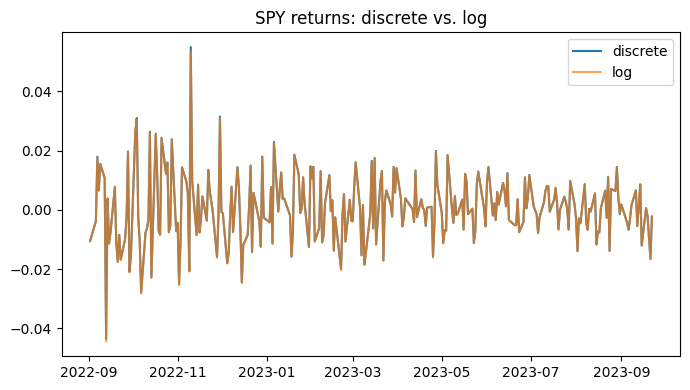

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(pd.to_datetime(discrete["Date"]), discrete["SPY"], label="discrete")
ax.plot(pd.to_datetime(log_ret["Date"]), log_ret["SPY"], label="log", alpha=0.7)
ax.set_title("SPY returns: discrete vs. log")
ax.legend()
fig.tight_layout()
plt.show()

## 7. Distribution fitting — Normal, Student's t, and the NIG

Every `fit_*` function returns a `FittedModel`: the fitted `error_model`
(a frozen `scipy.stats` distribution), a `.params` dict of the named
parameters, and (for regressions) `.beta`. `aicc` scores a fit against the
data it should explain, penalized for parameter count -- lower is better.

In [13]:
x71 = pd.read_csv(DATA / "test7_1.csv")["x1"].to_numpy()
normal_fit = rl.fit_normal(x71)
print("Normal fit:", normal_fit.params)

Normal fit: {'mu': np.float64(0.046771957516449095), 'sigma': np.float64(0.051789725724068626)}


Student's t fit: {'mu': np.float64(0.050100336388514716), 'sigma': np.float64(0.044955078823938524), 'nu': np.float64(4.092925758769519)}


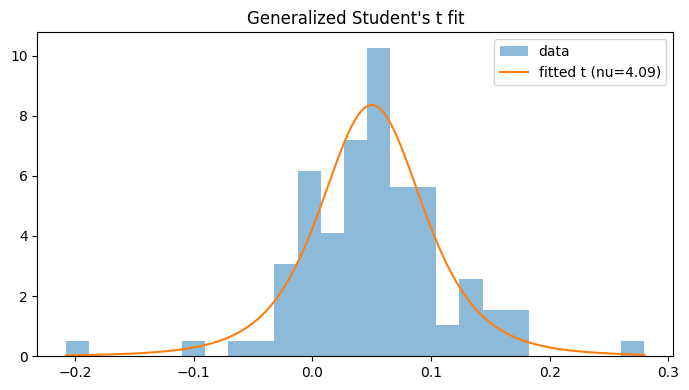

In [14]:
x72 = pd.read_csv(DATA / "test7_2.csv")["x1"].to_numpy()
t_fit = rl.fit_general_t(x72)
print("Student's t fit:", t_fit.params)

fig, ax = plt.subplots(figsize=(7, 4))
grid = np.linspace(x72.min(), x72.max(), 300)
ax.hist(x72, bins=25, density=True, alpha=0.5, label="data")
ax.plot(grid, t_fit.error_model.pdf(grid), label=f"fitted t (nu={t_fit.params['nu']:.2f})")
ax.legend()
ax.set_title("Generalized Student's t fit")
fig.tight_layout()
plt.show()

In [15]:
# AICc: penalizes the extra parameter count against the likelihood gain.
# fit_normal has 2 params (mu, sigma); fit_general_t has 3 (mu, sigma, nu).
from scipy import stats as _st

normal_on_x72 = rl.fit_normal(x72)
print("AICc, Normal fit to x72:      ", rl.aicc(normal_on_x72, x72))
print("AICc, Student's t fit to x72: ", rl.aicc(t_fit, x72))
print("(lower is better -- the heavier-tailed model should win comfortably if x72 truly has fat tails)")

AICc, Normal fit to x72:       -268.32391682185806
AICc, Student's t fit to x72:  -279.05462098490267
(lower is better -- the heavier-tailed model should win comfortably if x72 truly has fat tails)


In [16]:
# Regression with t-distributed errors: y ~ Alpha + B1*x1 + B2*x2 + B3*x3 + t-error
df73 = pd.read_csv(DATA / "test7_3.csv")
reg_fit = rl.fit_regression_t(df73["y"].to_numpy(), df73[["x1", "x2", "x3"]].to_numpy())
print("Regression coefficients (Alpha, B1, B2, B3):", np.round(reg_fit.beta, 4))
print("Error distribution:", {k: v for k, v in reg_fit.params.items() if k in ("sigma", "nu")})

Regression coefficients (Alpha, B1, B2, B3): [0.0496 1.1778 1.827  3.0564]
Error distribution: {'sigma': np.float64(0.050626305441370485), 'nu': np.float64(4.6619093234519005)}


### The NIG, two ways — the professor's specific question for this weekend

Same 1,000 observations, two different fitting criteria, same
`(mu, alpha, beta, delta)` parameterization:

- **`fit_nig_moments`**: closed form. Solves for the parameters that make
  the fitted distribution's mean/variance/skewness/excess-kurtosis exactly
  match the *sample's* mean/variance/skewness/excess-kurtosis.
- **`fit_nig_mle`**: numerical optimization (via `scipy.stats.norminvgauss.fit`).
  Solves for the parameters that maximize the likelihood of having observed
  this exact sample.

These optimize genuinely different objectives, so they land on different
parameters from the same data -- neither is "more correct."
Method-of-moments reproduces the sample's own skew/kurtosis exactly (by
construction) but doesn't maximize likelihood; MLE maximizes likelihood but
won't hit the sample moments exactly. Worth checking which one actually
reaches the higher log-likelihood below, and which one's skew/kurtosis
matches the raw sample more closely.

In [17]:
x75 = pd.read_csv(DATA / "test7_5.csv")["x1"].to_numpy()

moments_fit = rl.fit_nig_moments(x75)
mle_fit = rl.fit_nig_mle(x75)

print("method of moments:", {k: round(v, 4) for k, v in moments_fit.params.items()})
print("MLE:               ", {k: round(v, 4) for k, v in mle_fit.params.items()})

print("\nsample skewness / excess kurtosis: ", round(_st.skew(x75, bias=True), 5),
      "/", round(_st.kurtosis(x75, fisher=True, bias=True), 5))

ll_moments = np.sum(moments_fit.error_model.logpdf(x75))
ll_mle = np.sum(mle_fit.error_model.logpdf(x75))
print("log-likelihood, moments fit:", round(ll_moments, 2))
print("log-likelihood, MLE fit:    ", round(ll_mle, 2))

method of moments: {'mu': np.float64(0.0239), 'alpha': np.float64(52.9471), 'beta': np.float64(-12.2454), 'delta': np.float64(0.0575)}
MLE:                {'mu': np.float64(0.0197), 'alpha': np.float64(46.9236), 'beta': np.float64(-8.2327), 'delta': np.float64(0.0526)}

sample skewness / excess kurtosis:  -0.40329 / 1.23044
log-likelihood, moments fit: 1974.11
log-likelihood, MLE fit:     1974.54


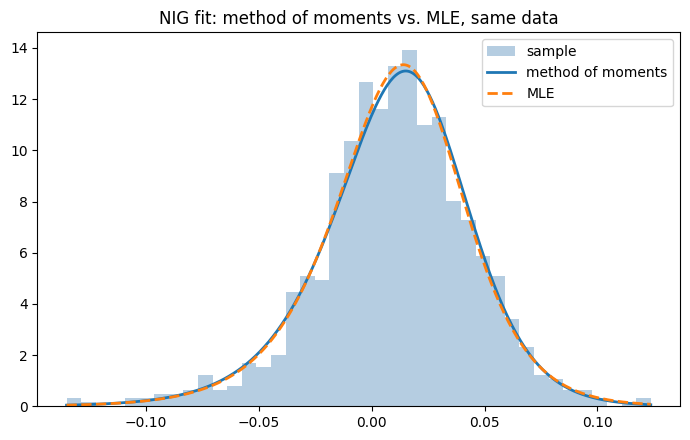

In [18]:
fig, ax = plt.subplots(figsize=(7, 4.5))
grid = np.linspace(x75.min(), x75.max(), 400)
ax.hist(x75, bins=40, density=True, alpha=0.4, label="sample", color="steelblue")
ax.plot(grid, moments_fit.error_model.pdf(grid), label="method of moments", lw=2)
ax.plot(grid, mle_fit.error_model.pdf(grid), label="MLE", lw=2, linestyle="--")
ax.legend()
ax.set_title("NIG fit: method of moments vs. MLE, same data")
fig.tight_layout()
plt.show()

## Running the full check

Everything demonstrated above is checked automatically, against the
reference `testout*.csv` files, in `tests/test_functional.py`. From the
repo root:

```
pytest tests/test_functional.py -v
```